In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import scanpy as sc

from tqdm.auto import tqdm

from cellina import CellinaModel
from utils import set_seed, plot_results, evaluate_models

/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Get dataset

In [3]:
set_seed(0)

In [4]:
#adata = sc.read_h5ad("/data2/a330d/datasets/synthetic_spatial_adata_processed.h5ad")
adata = sc.read("/data/a330d/projects/dsa/data/melanoma_cosmx_processed.h5ad")

# 1. Classifier

## Train

In [5]:
base_path = "/data2/a330d/data/cellina-reproducibility"

In [6]:
# Set holdout set for evaluation
fraction = 0.1
n_cells = adata.n_obs
n_holdout = int(n_cells * fraction)

# Randomly choose cells
holdout_idx = np.random.choice(n_cells, n_holdout, replace=False)

# Set 'is_holdout' to False by default, then True for selected cells
adata.obs['is_holdout'] = False
adata.obs.iloc[holdout_idx, adata.obs.columns.get_loc('is_holdout')] = True

In [7]:
adata_train = adata[~adata.obs["is_holdout"]].copy()

In [8]:
adata.layers.counts = adata.X.copy()

In [9]:
CellinaModel.setup_anndata(adata_train,
                           batch_key="CPID_str",
                           labels_key='celltype', 
                           domains_key='BEST_RESPONSE_BY_SCAN', 
                           spatial_obsm_key="neighborhood_pseudobulks",
                           spatial_connectivities_key='spatial_connectivities')

INFO     Generating sequential column names                                                                        


In [10]:
seeds = range(5)
alpha_ys = [0, 0.1, 10., 1000, 100000]

In [ ]:
epochs = 100
for alpha in tqdm(alpha_ys, desc="Training (alpha_y)"):
    for seed in seeds:
        set_seed(seed)
        model = CellinaModel(
            adata_train, n_latent=64, 
            classifier_lambda=alpha, 
            discriminator_lambda=1e2,
            link_prediction_weight=1e2,
        )
        model.train(
            max_epochs=epochs,
            check_val_every_n_epoch=1,
            early_stopping=True,
            early_stopping_patience=25,
            early_stopping_monitor="validation_loss",  # NOTE: z/e kl + reconstruction
            train_size=0.9,
            validation_size=0.1,
            plan_kwargs={
                "lr": 0.0001,
                "weight_decay": 0.0001,
            },
            enable_checkpointing=True,
            batch_size=2048,
            devices=[1],
        )

        model.save(f"{base_path}/ablation-edge/trained/alpha_y_{alpha}_seed_{seed}", overwrite=True)

## Eval

In [ ]:
df_alpha_y = evaluate_models(
    adata,
    seeds,
    alpha_type="alpha_y",
    alpha_values=alpha_ys,
    target_col="celltype",
    root_dir=f"{base_path}/ablation-edge/trained",
)

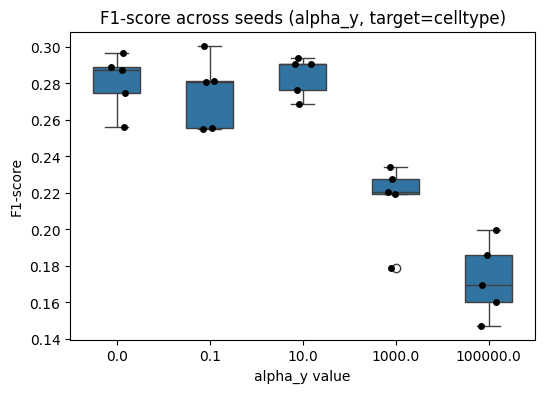

In [13]:
plot_results(df_alpha_y, alpha_type="alpha_y", target_col='celltype')

# 2. Discriminator

## Train

In [ ]:
alpha_ds = [0., 0.01, 5, 500, 500000]

In [ ]:
for alpha in tqdm(alpha_ds, desc="Training (alpha_d)"):
    for seed in seeds:
        set_seed(seed)
        model = CellinaModel(
            adata_train, n_latent=64, 
            classifier_lambda=1e2, 
            discriminator_lambda=alpha,
            link_prediction_weight=1e2,
        )
        model.train(
            max_epochs=epochs,
            check_val_every_n_epoch=1,
            early_stopping=True,
            early_stopping_patience=25,
            early_stopping_monitor="validation_loss",  # NOTE: z/e kl + reconstruction
            train_size=0.9,
            validation_size=0.1,
            plan_kwargs={
                "lr": 0.0001,
                "weight_decay": 0.0001,
            },
            enable_checkpointing=True,
            batch_size=2048,
            devices=[1],
        )

        model.save(f"{base_path}/ablation-edge/trained/alpha_d_{alpha}_seed_{seed}", overwrite=True)

Training (alpha_d):   0%|          | 0/1 [00:00<?, ?it/s]

INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting with edge prediction   


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


Epoch 1/1:   0%|          | 0/1 [00:00<?, ?it/s]

/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 51045. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 51038. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.


Epoch 1/1: 100%|██████████| 1/1 [00:16<00:00, 16.77s/it, v_num=1]

/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 49445. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
`Trainer.fit` stopped: `max_epochs=1` reached.


Epoch 1/1: 100%|██████████| 1/1 [00:16<00:00, 16.78s/it, v_num=1]


Training (alpha_d): 100%|██████████| 1/1 [00:17<00:00, 18.00s/it]


## Eval

In [ ]:
df_alpha_d = evaluate_models(
    adata,
    seeds,
    alpha_type="alpha_d",
    alpha_values=alpha_ds,
    target_col="BEST_RESPONSE_BY_SCAN",
    root_dir=f"{base_path}/ablation-edge/trained",
)

Evaluating (alpha_d):   0%|          | 0/1 [00:00<?, ?it/s]Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/ablation-edge/trained/alpha_d_0.01_seed_0/model.pt already 
         downloaded                                                                                                
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting with edge prediction   


Evaluating (alpha_d): 100%|██████████| 1/1 [00:01<00:00,  1.43s/it]


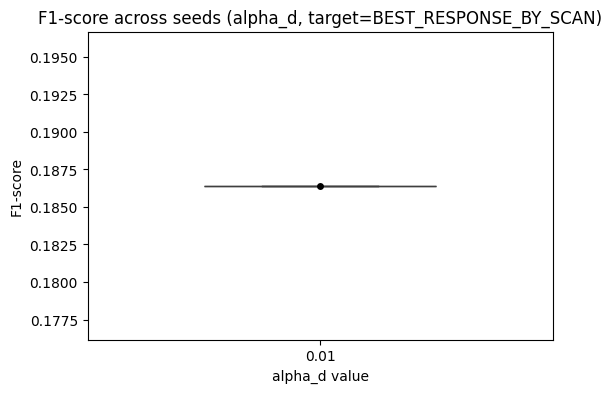

In [ ]:
plot_results(df_alpha_d, alpha_type="alpha_d", target_col='BEST_RESPONSE_BY_SCAN')

# 3. Edge predictor

## Train

In [ ]:
alpha_edge = [0., 0.01, 5, 1000, 1000000]

In [ ]:
for alpha in tqdm(alpha_edge, desc="Training (alpha_edge)"):
    for seed in seeds:
        set_seed(seed)
        model = CellinaModel(
            adata_train, n_latent=64, 
            classifier_lambda=1e2, 
            discriminator_lambda=1e2,
            link_prediction_weight=alpha,
        )
        model.train(
            max_epochs=epochs,
            check_val_every_n_epoch=1,
            early_stopping=True,
            early_stopping_patience=25,
            early_stopping_monitor="validation_loss",  # NOTE: z/e kl + reconstruction
            train_size=0.9,
            validation_size=0.1,
            plan_kwargs={
                "lr": 0.0001,
                "weight_decay": 0.0001,
            },
            enable_checkpointing=True,
            batch_size=2048,
            devices=[1],
        )

        model.save(f"{base_path}/ablation-edge/trained/alpha_edge_{alpha}_seed_{seed}", overwrite=True)

Training (alpha_edge):   0%|          | 0/1 [00:00<?, ?it/s]

INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting with edge prediction   


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


Epoch 1/1:   0%|          | 0/1 [00:00<?, ?it/s]

/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 50973. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 51057. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.


Epoch 1/1: 100%|██████████| 1/1 [00:17<00:00, 17.07s/it, v_num=1]

/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 50138. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
`Trainer.fit` stopped: `max_epochs=1` reached.


Epoch 1/1: 100%|██████████| 1/1 [00:17<00:00, 17.08s/it, v_num=1]


Training (alpha_edge): 100%|██████████| 1/1 [00:18<00:00, 18.37s/it]


## Eval

In [ ]:
df_alpha_edge = evaluate_models(
    adata,
    seeds,
    alpha_type="alpha_edge",
    alpha_values=alpha_edge,
    target_col="BEST_RESPONSE_BY_SCAN",
    latent_key='s',
    root_dir=f"{base_path}/ablation-edge/trained",
)

Evaluating (alpha_edge):   0%|          | 0/1 [00:00<?, ?it/s]Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/ablation-edge/trained/alpha_edge_0.01_seed_0/model.pt      
         already downloaded                                                                                        
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting with edge prediction   


Evaluating (alpha_edge): 100%|██████████| 1/1 [00:01<00:00,  1.43s/it]


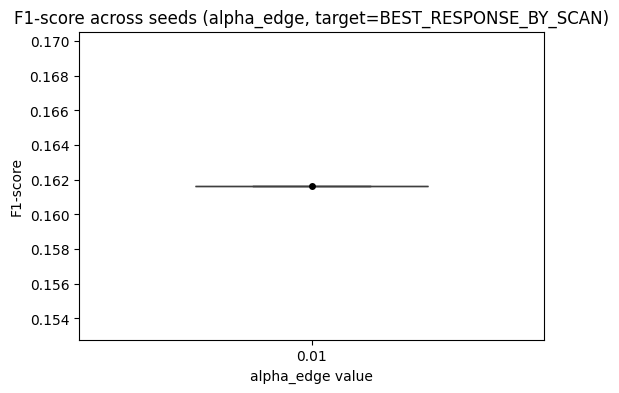

In [ ]:
plot_results(df_alpha_edge, alpha_type="alpha_edge", target_col='BEST_RESPONSE_BY_SCAN')